## Chapter39: Hyperparameters and Model Validation

---
* Author:  [Yuttapong Mahasittiwat](mailto:khala1391@gmail.com)
* Technologist | Data Modeler | Data Analyst
* [YouTube](https://www.youtube.com/khala1391)
* [LinkedIn](https://www.linkedin.com/in/yuttapong-m/)
---

Source: [**Python Data Science Handbook** by **VanderPlas**](https://jakevdp.github.io/PythonDataScienceHandbook/)

In [1]:
import numpy as np
import pandas as pd
print("numpy version :",np.__version__)
print("pandas version :",pd.__version__)

numpy version : 1.26.4
pandas version : 2.2.3


### Thinking about model validatioan

### Selecting the best model

In [2]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

def PolynomialRegression(degree=2, **kwargs):
    return make_pipeline(PolynomialFeatures(degree),
                         LinearRegression(**kwargs))

In [3]:
import numpy as np

def make_data(N, err=1.0, rseed=1):
    rng = np.random.RandomState(rseed)
    X= rng.rand(N,1)**2
    y = 10 -1/(X.ravel()+ 0.1)
    if err > 0:
        y +=err * rng.randn(N)
    return X,y

In [4]:
X,y = make_data(40)

In [5]:
import matplotlib.pyplot as plt
# plt.style.use('se')

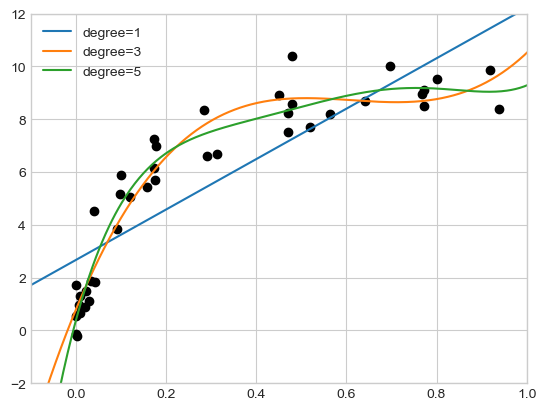

In [6]:
plt.style.use('seaborn-v0_8-whitegrid')
X_test = np.linspace(-.1, 1.1, 500)[:,None]  # same as [:, np.newaxis]

plt.scatter(X.ravel(), y, color='black')
axis = plt.axis()
for degree in [1,3,5]:
    y_test = PolynomialRegression(degree).fit(X,y).predict(X_test)
    plt.plot(X_test.ravel(), y_test, label=f'degree={degree}')
    plt.xlim(-0.1,1)
    plt.ylim(-2,12)
    plt.legend(loc='best')

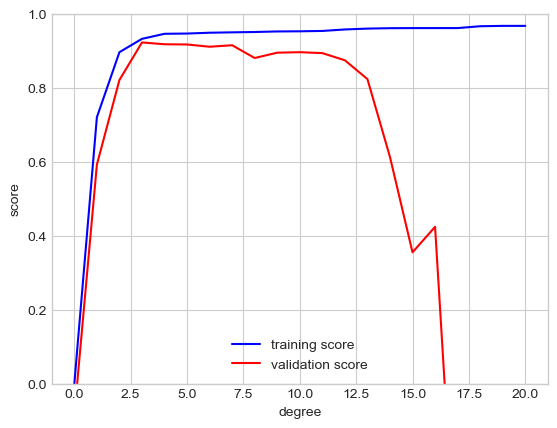

In [7]:
from sklearn.model_selection import validation_curve
degree = np.arange(0,21)
train_score, val_score = validation_curve(
    PolynomialRegression(),X,y,
    param_name='polynomialfeatures__degree',
    param_range=degree, cv=7)

plt.plot(degree,np.median(train_score,1),
         color = 'blue', label='training score')
plt.plot(degree, np.median(val_score,1),
         color ='red', label='validation score')
plt.legend(loc='best')
plt.ylim(0,1)
plt.xlabel('degree')
plt.ylabel('score');

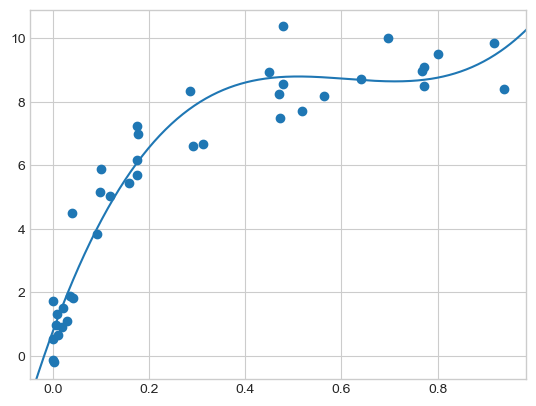

In [8]:
plt.scatter(X.ravel(),y)
lim = plt.axis()
y_test =  PolynomialRegression(3).fit(X,y).predict(X_test)
plt.plot(X_test.ravel(), y_test)
plt.axis(lim);

### Learning Curves

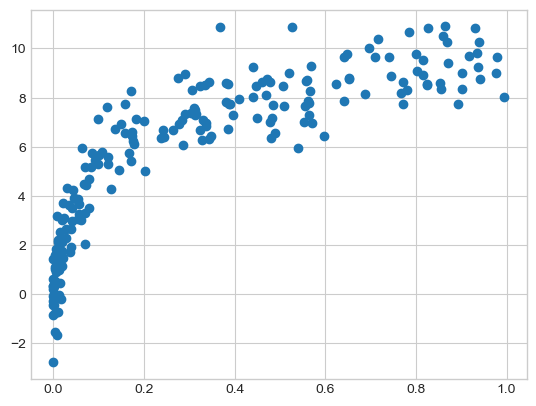

In [12]:
X2, y2 = make_data(200)
plt.scatter(X2.ravel(), y2);

Text(0, 0.5, 'score')

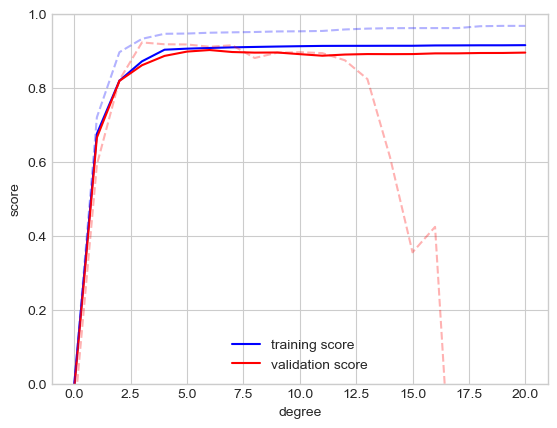

In [29]:
degree =np.arange(21)
train_score2, val_score2 = validation_curve(
    PolynomialRegression(), X2,y2,
    param_name='polynomialfeatures__degree',
    param_range=degree, cv=7)

plt.plot(degree, np.median(train_score2,1),
         color='blue', label='training score')
plt.plot(degree, np.median(val_score2,1),
         color='red', label='validation score')
plt.plot(degree, np.median(train_score,1),
         color='blue', alpha=0.3, linestyle='dashed')
plt.plot(degree, np.median(val_score,1),
         color='red', alpha=0.3, linestyle='dashed')
plt.legend(loc='lower center')
plt.ylim(0,1)
plt.xlabel('degree')
plt.ylabel('score')

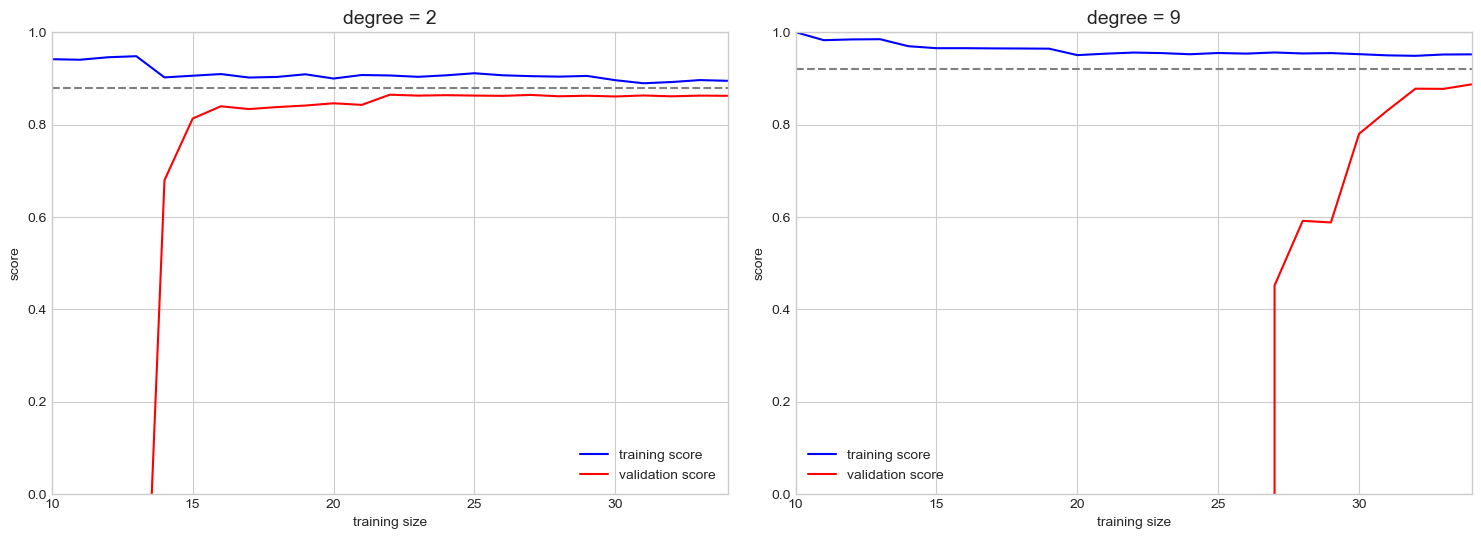

In [20]:
from sklearn.model_selection import learning_curve

fig, ax = plt.subplots(1,2, figsize=(16,6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for i, degree in enumerate([2,9]):
    N, train_lc, val_lc = learning_curve(
        PolynomialRegression(degree), X,y, cv=7,
        train_sizes=np.linspace(0.3,1,25)
    )

    ax[i].plot(N, np.mean(train_lc,1),
               color='blue', label='training score')
    ax[i].plot(N, np.mean(val_lc,1),
               color='red', label='validation score')
    ax[i].hlines(np.mean([train_lc[-1], val_lc[-1]]), N[0],
                N[-1],color='gray', linestyle='dashed')
    ax[i].set_ylim(0,1)
    ax[i].set_xlim(N[0], N[-1])
    ax[i].set_xlabel('training size')
    ax[i].set_ylabel('score')
    ax[i].set_title('degree = {0}'.format(degree), size=14)
    ax[i].legend(loc='best')

### Validation in Practice: Grid Search

In [30]:
from sklearn.model_selection import GridSearchCV

param_grid = {'polynomialfeatures__degree': np.arange(21),
              'linearregression__fit_intercept': [True,False]}
grid = GridSearchCV(PolynomialRegression(), param_grid, cv=7)

In [31]:
grid.fit(X,y)

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('polynomialfeatures',
                                        PolynomialFeatures()),
                                       ('linearregression',
                                        LinearRegression())]),
             param_grid={'linearregression__fit_intercept': [True, False],
                         'polynomialfeatures__degree': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20])})

In [32]:
grid.best_params_

{'linearregression__fit_intercept': False, 'polynomialfeatures__degree': 4}

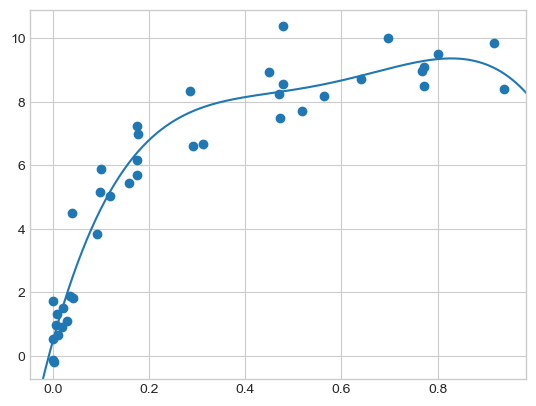

In [34]:
model = grid.best_estimator_

plt.scatter(X.ravel(),y)
lim = plt.axis()
y_test = model.fit(X,y).predict(X_test)
plt.plot(X_test.ravel(), y_test)
plt.axis(lim);